In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Load Dataset

In [37]:
df = pd.read_csv('/content/sample_data/nlp_dataset.csv')
df.head()

,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5937 entries, 0 to 5936
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Comment  5937 non-null   object
 1   Emotion  5937 non-null   object
dtypes: object(2)
memory usage: 92.9+ KB


In [39]:
df.isnull().sum()

,0
Comment,0
Emotion,0


In [40]:
df['Emotion'].value_counts()

,count
Emotion,
anger,2000
joy,2000
fear,1937


Text Preprocessing

In [41]:
stop_words = set(stopwords.words('english'))
def preprocess(text):
    #lowercase
    text = text.lower()
    #URL removing
    text = re.sub(r'http\S+', '', text)
    #punctution and number removing
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Simple tokenization
    words = text.split()
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    return " ".join(words)
df["Clean_Text"] = df["Comment"].apply(preprocess)
df.head()

,Comment,Emotion,Clean_Text
0,i seriously hate one subject to death but now ...,fear,seriously hate one subject death feel reluctan...
1,im so full of life i feel appalled,anger,im full life feel appalled
2,i sit here to write i start to dig out my feel...,fear,sit write start dig feelings think afraid acce...
3,ive been really angry with r and i feel like a...,joy,ive really angry r feel like idiot trusting fi...
4,i feel suspicious if there is no one outside l...,fear,feel suspicious one outside like rapture happe...


Feature Extraction (TF-IDF)

In [42]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['Clean_Text'])
y = df['Emotion']

Train-Test Split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

Model 1 - Naive Bayes Model

In [44]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)
print("Naive Bayes Accuracy:", nb_accuracy)
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.9099326599326599
              precision    recall  f1-score   support

       anger       0.88      0.95      0.91       392
        fear       0.92      0.92      0.92       416
         joy       0.95      0.86      0.90       380

    accuracy                           0.91      1188
   macro avg       0.91      0.91      0.91      1188
weighted avg       0.91      0.91      0.91      1188



[[372  12   8]
 [ 23 382  11]
 [ 30  23 327]]


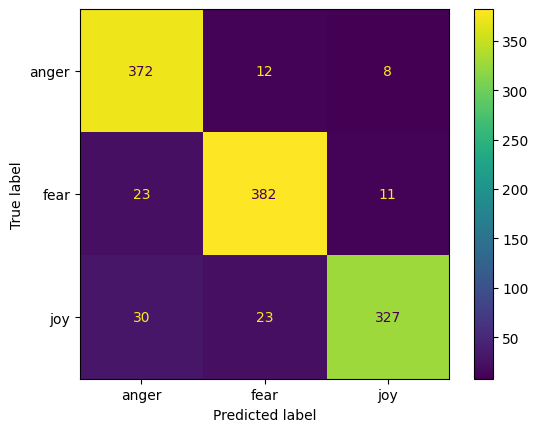

In [53]:
print(confusion_matrix(y_test, nb_pred))
ConfusionMatrixDisplay.from_predictions(y_test, nb_pred)
plt.show()

Model 2 – Support Vector Machine

In [50]:
svm = LinearSVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", svm_accuracy)
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.952020202020202
              precision    recall  f1-score   support

       anger       0.94      0.96      0.95       392
        fear       0.97      0.93      0.95       416
         joy       0.95      0.97      0.96       380

    accuracy                           0.95      1188
   macro avg       0.95      0.95      0.95      1188
weighted avg       0.95      0.95      0.95      1188



[[375   8   9]
 [ 18 388  10]
 [  6   6 368]]


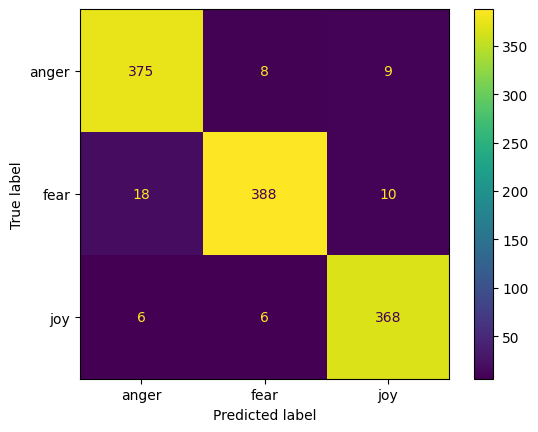

In [52]:
print(confusion_matrix(y_test, svm_pred))
ConfusionMatrixDisplay.from_predictions(y_test, svm_pred)
plt.show()

Model Comparison

In [54]:
comparison = pd.DataFrame({
    'Model':['Naive Bayes','Support Vector Machine'],
    'Accuracy':[nb_accuracy, svm_accuracy]
})
comparison

,Model,Accuracy
0,Naive Bayes,0.909933
1,Support Vector Machine,0.952020


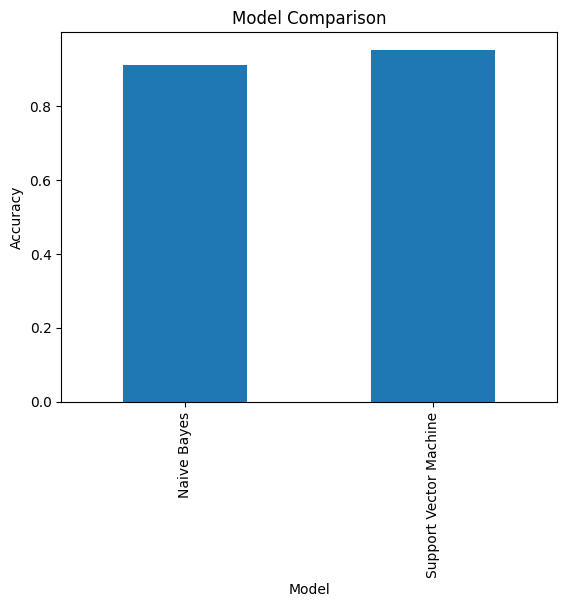

In [55]:
comparison.plot(x='Model', y='Accuracy', kind='bar', legend=False)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

**Conclusion**

*   **Naive Bayes:** A probabilistic classifier that is simple, fast, and effective for text classification tasks. It assumes that features are independent, which makes it computationally efficient.

*   **Support Vector Machine (SVM):** A discriminative classifier that finds the optimal decision boundary between classes. It is particularly effective for high-dimensional text data such as TF-IDF vectors.

